In [1]:
from datasets.batch_integration import BatchIntDataset
from utils.experiment_utils import get_all_experiments_info, load_best_model
from utils.eval_utils import compute_mmd_distance, compute_sw_distance
import os

import scvi
import scanpy as sc
import pandas as pd
from collections import defaultdict
from sklearn.neighbors import NearestNeighbors

import hydra
from omegaconf import OmegaConf

import torch
import numpy as np
from geomloss import SamplesLoss

import harmonypy as hm

# silence all warnings
import warnings
warnings.filterwarnings("ignore")

/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
n_pcs = 10
train_set = BatchIntDataset(
    root="data",
    split="train",
    n_pcs=n_pcs
)

test_set = BatchIntDataset(
    root="data",
    split="test",
    n_pcs=n_pcs
)

data loaded !
n train donors: 53
n test donors: 3
data loaded !
n train donors: 53
n test donors: 3


In [3]:
adata = test_set.adata
full_adata = train_set.adata.concatenate(test_set.adata)

In [4]:
train_donors = train_set.donors
test_donors = test_set.donors
print(train_donors)
print(test_donors)

['mouse_pancreatic_islet_atlas_Hrovatin__Fltp_P16__145_mGFP', 'mouse_pancreatic_islet_atlas_Hrovatin__Fltp_P16__146_mRFP', 'mouse_pancreatic_islet_atlas_Hrovatin__Fltp_P16__147_mTmG', 'mouse_pancreatic_islet_atlas_Hrovatin__Fltp_adult__mouse1', 'mouse_pancreatic_islet_atlas_Hrovatin__Fltp_adult__mouse2', 'mouse_pancreatic_islet_atlas_Hrovatin__Fltp_adult__mouse3', 'mouse_pancreatic_islet_atlas_Hrovatin__Fltp_adult__mouse4', 'mouse_pancreatic_islet_atlas_Hrovatin__NOD__SRR10985097', 'mouse_pancreatic_islet_atlas_Hrovatin__NOD__SRR10985098', 'mouse_pancreatic_islet_atlas_Hrovatin__NOD__SRR10985099', 'mouse_pancreatic_islet_atlas_Hrovatin__NOD_elimination__SRR7610295', 'mouse_pancreatic_islet_atlas_Hrovatin__NOD_elimination__SRR7610296', 'mouse_pancreatic_islet_atlas_Hrovatin__NOD_elimination__SRR7610297', 'mouse_pancreatic_islet_atlas_Hrovatin__NOD_elimination__SRR7610298', 'mouse_pancreatic_islet_atlas_Hrovatin__NOD_elimination__SRR7610299', 'mouse_pancreatic_islet_atlas_Hrovatin__NOD_e

In [5]:
donor_centroids = {}
for donor in test_donors:
    donor_data = test_set.adata[test_set.adata.obs['donor_id'] == donor]
    centroid = np.nan_to_num(donor_data.obsm['X_pca']).mean(axis=0).flatten()
    donor_centroids[donor] = centroid
for donor in train_donors:
    donor_data = train_set.adata[train_set.adata.obs['donor_id'] == donor]
    centroid = np.nan_to_num(donor_data.obsm['X_pca']).mean(axis=0).flatten()
    donor_centroids[donor] = centroid

# for each test donor, get the nearest train donor
test_to_train_donor = {}
for test_donor in test_donors:
    test_centroid = donor_centroids[test_donor]
    nearest_train_donor = None
    nearest_distance = float('inf')
    for train_donor in train_donors:
        train_centroid = donor_centroids[train_donor]
        distance = torch.norm(torch.tensor(test_centroid) - torch.tensor(train_centroid)).item()
        if distance < nearest_distance:
            nearest_distance = distance
            nearest_train_donor = train_donor
    test_to_train_donor[test_donor] = nearest_train_donor

print("Test to Train Donor Mapping:")
for test_donor, train_donor in test_to_train_donor.items():
    print(f"{test_donor} -> {train_donor}")

Test to Train Donor Mapping:
mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13974 -> mouse_pancreatic_islet_atlas_Hrovatin__VSG__MUC13632
mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13975 -> mouse_pancreatic_islet_atlas_Hrovatin__VSG__MUC13639
mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13976 -> mouse_pancreatic_islet_atlas_Hrovatin__VSG__MUC13634


In [6]:
configs = get_all_experiments_info('/orcd/home/002/gokulg/orcd/scratch/CoupledDistributionEmbeddings/outputs/', False)

cfgs = [c for c in configs if 'batchint' in c['name']]

energy_models = [c for c in cfgs if 'mmd' in c['config']['generator'].values()]
                #  and (c['config']['training']['num_epochs'] == 5000 or 'onehot' in c['name'])]
swd_models = [c for c in cfgs if 'swd' in c['config']['generator'].values()]
            #   and (c['config']['training']['num_epochs'] == 5000 or 'onehot' in c['name'])]
fm_models = [c for c in cfgs if 'Flow' in c['generator']]
            #  and (c['config']['training']['num_epochs'] == 5000 or 'onehot' in c['name'])]

print("energy models:")
for model in energy_models:
    print(model['name'])

print("fm models:")
for model in fm_models:
    print(model['name'])

print("swd models:")
for model in swd_models:
    print(model['name'])

energy models:
batchint_51fd5cc1e1cb76538d5e871f133014cc
batchint_onehot_mmd_1d4aef25103928c4fc6492767556faf3
fm models:
batchint_fm_dab5345122fa4556bd624bc4fcafa3dd
batchint_onehot_fm_574ff0b31ab003138bfc8b88e22b7e4c
swd models:
batchint_54db9e4d1d2ac64c78877f1e06a00d6f
batchint_onehot_mmd_26fccba7ca909d547cf875090578d419
batchint_onehot_mmd_6ed9888422f7d203216a45c6fcb099c7


In [7]:
def load_model(cfg, path, device):
    enc = hydra.utils.instantiate(cfg['encoder'])
    gen = hydra.utils.instantiate(cfg['generator'])
    state = load_best_model(path)
    enc.load_state_dict(state['encoder_state_dict'])
    gen.load_state_dict(state['generator_state_dict'])
    enc.eval()
    gen.eval()
    enc.to(device)
    gen.to(device)
    return enc, gen

In [8]:
def evaluate_model_pair(encoder, generator, test_set, train_set, test_to_train_donor, 
                        model_type, device, n_pcs=10, n_samples=10):

    energy = SamplesLoss("energy")
    
    results = {
        'energy': [],
        'mmd': [],
        'sw': []
    }
    
    for p in range(len(test_set)):
        for _ in range(n_samples):
            batch = test_set[p]
            
            source_samples = batch['source_samples'].to(device).unsqueeze(0)
            target_samples = batch['target_samples'].to(device).unsqueeze(0)
            
            # Generate samples based on model type
            if model_type == 'onehot':
                source_donor = batch['source_metadata']['donor_id']
                target_donor = batch['target_metadata']['donor_id']
                
                nearest_source_donor = test_to_train_donor[source_donor]
                nearest_target_donor = test_to_train_donor[target_donor]
                
                nn_source_idx = torch.tensor(train_set.donors.index(nearest_source_donor)).to(device)
                nn_target_idx = torch.tensor(train_set.donors.index(nearest_target_donor)).to(device)
                
                with torch.no_grad():
                    source_latent = encoder(nn_source_idx).repeat(source_samples.shape[0], 1)
                    target_latent = encoder(nn_target_idx).repeat(target_samples.shape[0], 1)
                    samples = generator.sample(source_samples.reshape(-1, n_pcs), source_latent, target_latent)
            else: 
                with torch.no_grad():
                    source_latent = encoder(source_samples)
                    target_latent = encoder(target_samples)
                    samples = generator.sample(source_samples.reshape(-1, n_pcs), source_latent, target_latent)
            
            # Compute all metrics
            results['energy'].append(energy(samples.squeeze(0), target_samples.squeeze(0)).item())
            results['mmd'].append(compute_mmd_distance(samples, target_samples).item())
            results['sw'].append(compute_sw_distance(samples, target_samples).item())
    
    return results

device = 'cuda'
all_results = {}

model_pairs = [
    ('energy_models', energy_models),
    ('fm_models', fm_models),
    ('swd_models', swd_models)
]

for model_group_name, model_group in model_pairs:
    print(f"evaluating {model_group_name}")
        
    dct_model = [c for c in model_group if 'Emb' not in c['encoder']]
    onehot_model = [c for c in model_group if 'Emb' in c['encoder']]
    
    if not dct_model or not onehot_model:
        print(f"Skipping {model_group_name}: missing DCT or OneHot model")
        continue
    
    dct_model = dct_model[0]
    onehot_model = onehot_model[0]
    
    dct_encoder, dct_generator = load_model(dct_model['config'], dct_model['dir'], device)
    dct_results = evaluate_model_pair(
        dct_encoder, dct_generator, test_set, train_set, 
        test_to_train_donor, 'dct', device, n_pcs=n_pcs
    )
    all_results[f'{model_group_name}_dct'] = dct_results
    
    onehot_encoder, onehot_generator = load_model(onehot_model['config'], onehot_model['dir'], device)
    onehot_results = evaluate_model_pair(
        onehot_encoder, onehot_generator, test_set, train_set,
        test_to_train_donor, 'onehot', device, n_pcs=n_pcs
    )
    all_results[f'{model_group_name}_onehot'] = onehot_results

print(f"{'Model':<30} {'Energy':<20} {'MMD':<20} {'SW':<20}")

for model_name, results in all_results.items():
    energy_str = f"{np.mean(results['energy']):.4f}\pm{np.std(results['energy'])/np.sqrt(len(results['energy'])):.4f}"
    mmd_str = f"{np.mean(results['mmd']):.4f}\pm{np.std(results['mmd'])/np.sqrt(len(results['mmd'])):.4f}"
    sw_str = f"{np.mean(results['sw']):.4f}\pm{np.std(results['sw'])/np.sqrt(len(results['sw'])):.4f}"
    print(f"{model_name:<30} {energy_str:<20} {mmd_str:<20} {sw_str:<20}")

evaluating energy_models
evaluating fm_models
evaluating swd_models
Model                          Energy               MMD                  SW                  
energy_models_dct              0.0639\pm0.0046      0.1278\pm0.0092      0.4248\pm0.0257     
energy_models_onehot           0.4000\pm0.0453      0.8000\pm0.0905      0.6222\pm0.0333     
fm_models_dct                  0.0733\pm0.0119      0.1466\pm0.0238      0.3309\pm0.0436     
fm_models_onehot               0.2429\pm0.0385      0.4858\pm0.0770      0.4659\pm0.0390     
swd_models_dct                 0.1164\pm0.0118      0.2329\pm0.0236      0.3051\pm0.0298     
swd_models_onehot              0.3160\pm0.0286      0.6319\pm0.0571      0.5164\pm0.0226     


In [9]:
# scVI model evaluation with all three metrics
adata_scvi = adata.copy()

scvi.model.SCVI.setup_anndata(
    adata_scvi,
    batch_key="donor_id",
    layer='counts'
)

model = scvi.model.SCVI.load('/orcd/home/002/gokulg/orcd/scratch/CoupledDistributionEmbeddings/outputs/batch_scvi_model', adata_scvi)

# fit nearest neighbors on adata
nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(adata_scvi.X)

energy = SamplesLoss("energy")

all_results['scvi'] = {
    'energy': [],
    'mmd': [],
    'sw': []
}

for p in range(len(test_set)):
    batches_info = []
    for _ in range(10):
        batch = test_set[p]
        batches_info.append(batch)
    
    # Group by target donor to batch the scVI calls
    donor_groups = defaultdict(list)
    for i, batch in enumerate(batches_info):
        target_donor = batch['target_metadata']['donor_id']
        donor_groups[target_donor].append((i, batch))
    
    # Process each donor group together
    results = [None] * 10
    for target_donor, group in donor_groups.items():
        # Combine all source indices for this target donor
        all_source_inds = np.concatenate([b['source_metadata']['adata_indices'] for _, b in group])
        adata_source = adata_scvi[all_source_inds].copy()
        
        # Single scVI call for all samples going to this donor
        transformed = model.get_normalized_expression(
            adata_source, batch_size=512, transform_batch=target_donor
        )
        
        # Split results back
        offset = 0
        for i, batch in group:
            n_samples = len(batch['source_metadata']['adata_indices'])
            results[i] = (transformed[offset:offset+n_samples], batch['target_samples'])
            offset += n_samples
    
    # Compute all three metrics
    for transformed, target_samples in results:
        nns = nbrs.kneighbors(transformed, return_distance=False)
        snapped = adata_scvi.obsm['X_pca'][nns.flatten(), :10]
        
        # Convert to torch tensor
        snapped_tensor = torch.tensor(snapped, dtype=torch.float32)
        
        # Compute energy distance
        e_dist = energy(snapped_tensor, target_samples.squeeze(0)).item()
        all_results['scvi']['energy'].append(e_dist)
        
        # Compute MMD distance
        mmd_dist = compute_mmd_distance(snapped_tensor.unsqueeze(0), target_samples).item()
        all_results['scvi']['mmd'].append(mmd_dist)
        
        # Compute SW distance
        sw_dist = compute_sw_distance(snapped_tensor.unsqueeze(0), target_samples).item()
        all_results['scvi']['sw'].append(sw_dist)

print(f"{'Model':<30} {'Energy':<20} {'MMD':<20} {'SW':<20}")
for model_name, results in all_results.items():
    energy_str = f"{np.mean(results['energy']):.4f}\pm{np.std(results['energy'])/np.sqrt(len(results['energy'])):.4f}"
    mmd_str = f"{np.mean(results['mmd']):.4f}\pm{np.std(results['mmd'])/np.sqrt(len(results['mmd'])):.4f}"
    sw_str = f"{np.mean(results['sw']):.4f}\pm{np.std(results['sw'])/np.sqrt(len(results['sw'])):.4f}"

    print(f"{model_name:<30} {energy_str:<20} {mmd_str:<20} {sw_str:<20}")

INFO     File /orcd/home/002/gokulg/orcd/scratch/CoupledDistributionEmbeddings/outputs/batch_scvi_model/model.pt   
         already downloaded                                                                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer set

In [10]:
adata_harmony = full_adata.copy()
pcs = adata_harmony.obsm['X_pca']
harmony_out = hm.run_harmony(pcs, adata_harmony.obs, "donor_id")
adata_harmony.obsm['X_pca_harmony'] = harmony_out.Z_corr
harmony_latent = adata_harmony.obsm["X_pca_harmony"][:, :n_pcs]

n_train = 0#len(train_set.adata)  # offset for test cell indices in full_adata

harmony_nbrs = {}
harmony_pca = {}
for donor in test_donors:
    # train_donor = test_to_train_donor[donor]
    # mask = adata_harmony.obs["donor_id"] == train_donor
    mask = adata_harmony.obs['donor_id'] == donor
    harmony_nbrs[donor] = NearestNeighbors(n_neighbors=1, algorithm="ball_tree").fit(
        harmony_latent[mask]
    )
    harmony_pca[donor] = adata_harmony.obsm["X_pca"][mask][:, :n_pcs]

energy = SamplesLoss("energy")

all_results["harmony"] = {
    "energy": [],
    "mmd": [],
    "sw": [],
}

for p in range(len(test_set)):
    batches_info = []
    for _ in range(10):
        batch = test_set[p]
        batches_info.append(batch)

    for batch in batches_info:
        source_inds = batch["source_metadata"]["adata_indices"]
        target_donor = batch["target_metadata"]["donor_id"]
        target_samples = batch["target_samples"]

        source_harmony = harmony_latent[n_train + source_inds]  # offset into full_adata
        _, indices = harmony_nbrs[target_donor].kneighbors(source_harmony)
        snapped = harmony_pca[target_donor][indices.flatten()]

        snapped_tensor = torch.tensor(snapped, dtype=torch.float32)

        all_results["harmony"]["energy"].append(
            energy(snapped_tensor, target_samples.squeeze(0)).item()
        )
        all_results["harmony"]["mmd"].append(
            compute_mmd_distance(snapped_tensor.unsqueeze(0), target_samples).item()
        )
        all_results["harmony"]["sw"].append(
            compute_sw_distance(snapped_tensor.unsqueeze(0), target_samples).item()
        )

print(f"{'Model':<30} {'Energy':<20} {'MMD':<20} {'SW':<20}")
for model_name, results in all_results.items():
    energy_str = f"{np.mean(results['energy']):.4f}\pm{np.std(results['energy'])/np.sqrt(len(results['energy'])):.4f}"
    mmd_str = f"{np.mean(results['mmd']):.4f}\pm{np.std(results['mmd'])/np.sqrt(len(results['mmd'])):.4f}"
    sw_str = f"{np.mean(results['sw']):.4f}\pm{np.std(results['sw'])/np.sqrt(len(results['sw'])):.4f}"
    print(f"{model_name:<30} {energy_str:<20} {mmd_str:<20} {sw_str:<20}")


2026-02-22 20:19:56,004 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-02-22 20:19:56,005 - harmonypy - INFO -   Parameters:
2026-02-22 20:19:56,006 - harmonypy - INFO -     max_iter_harmony: 10
2026-02-22 20:19:56,007 - harmonypy - INFO -     max_iter_kmeans: 20
2026-02-22 20:19:56,008 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-02-22 20:19:56,009 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-02-22 20:19:56,009 - harmonypy - INFO -     nclust: 100
2026-02-22 20:19:56,011 - harmonypy - INFO -     block_size: 0.05
2026-02-22 20:19:56,012 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
2026-02-22 20:19:56,012 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 

Model                          Energy               MMD                  SW                  
energy_models_dct              0.0639\pm0.0046      0.1278\pm0.0092      0.4248\pm0.0257     
energy_models_onehot           0.4000\pm0.0453      0.8000\pm0.0905      0.6222\pm0.0333     
fm_models_dct                  0.0733\pm0.0119      0.1466\pm0.0238      0.3309\pm0.0436     
fm_models_onehot               0.2429\pm0.0385      0.4858\pm0.0770      0.4659\pm0.0390     
swd_models_dct                 0.1164\pm0.0118      0.2329\pm0.0236      0.3051\pm0.0298     
swd_models_onehot              0.3160\pm0.0286      0.6319\pm0.0571      0.5164\pm0.0226     
scvi                           0.9074\pm0.0698      1.8147\pm0.1395      0.6643\pm0.0566     
harmony                        0.0903\pm0.0086      0.1806\pm0.0173      0.4411\pm0.0185     


In [11]:
table_data = []

model_groups = [
    ('energy_models', 'Energy'),
    ('fm_models', 'Flow Matching'),
    ('swd_models', 'Sliced-Wasserstein')
]

for group_name, display_name in model_groups:
    for encoder_type in ['dct', 'onehot']:
        model_key = f'{group_name}_{encoder_type}'
        if model_key in all_results:
            results = all_results[model_key]
            
            # Compute mean ± SEM for each metric
            energy_mean = np.mean(results['energy'])
            energy_sem = np.std(results['energy']) / np.sqrt(len(results['energy']))
            
            sw_mean = np.mean(results['sw'])
            sw_sem = np.std(results['sw']) / np.sqrt(len(results['sw']))
            
            mmd_mean = np.mean(results['mmd'])
            mmd_sem = np.std(results['mmd']) / np.sqrt(len(results['mmd']))
            
            encoder_display = 'DCT' if encoder_type == 'dct' else 'One-hot'
            model_name = f'{encoder_display} ({display_name})'
            
            table_data.append({
                'Model': model_name,
                'Energy': f'{energy_mean:.4f} $\\pm$ {energy_sem:.4f}',
                'SW': f'{sw_mean:.4f} $\\pm$ {sw_sem:.4f}',
                'MMD': f'{mmd_mean:.4f} $\\pm$ {mmd_sem:.4f}'
            })
    
    table_data.append({'separator': True})

if 'scvi' in all_results:
    results = all_results['scvi']
    
    energy_mean = np.mean(results['energy'])
    energy_sem = np.std(results['energy']) / np.sqrt(len(results['energy']))
    
    sw_mean = np.mean(results['sw'])
    sw_sem = np.std(results['sw']) / np.sqrt(len(results['sw']))
    
    mmd_mean = np.mean(results['mmd'])
    mmd_sem = np.std(results['mmd']) / np.sqrt(len(results['mmd']))
    
    table_data.append({
        'Model': 'scVI',
        'Energy': f'{energy_mean:.4f} $\\pm$ {energy_sem:.4f}',
        'SW': f'{sw_mean:.4f} $\\pm$ {sw_sem:.4f}',
        'MMD': f'{mmd_mean:.4f} $\\pm$ {mmd_sem:.4f}'
    })

if 'harmony' in all_results:
    results = all_results['harmony']
    
    energy_mean = np.mean(results['energy'])
    energy_sem = np.std(results['energy']) / np.sqrt(len(results['energy']))
    
    sw_mean = np.mean(results['sw'])
    sw_sem = np.std(results['sw']) / np.sqrt(len(results['sw']))
    
    mmd_mean = np.mean(results['mmd'])
    mmd_sem = np.std(results['mmd']) / np.sqrt(len(results['mmd']))
    
    table_data.append({
        'Model': 'Harmony',
        'Energy': f'{energy_mean:.4f} $\\pm$ {energy_sem:.4f}',
        'SW': f'{sw_mean:.4f} $\\pm$ {sw_sem:.4f}',
        'MMD': f'{mmd_mean:.4f} $\\pm$ {mmd_sem:.4f}'
    })

# Generate LaTeX table
latex_lines = [
    r'\begin{tabular}{lccc}',
    r'\toprule',
    r'Model & Energy Distance & Sliced-Wasserstein & MMD (RBF) \\',
    r'\midrule'
]

for row in table_data:
    if row.get('separator'):
        latex_lines.append(r'\midrule')
    else:
        latex_lines.append(f"{row['Model']} & {row['Energy']} & {row['SW']} & {row['MMD']} \\\\")

latex_lines.extend([
    r'\bottomrule',
    r'\end{tabular}'
])

latex_table = '\n'.join(latex_lines)
print(latex_table)

\begin{tabular}{lccc}
\toprule
Model & Energy Distance & Sliced-Wasserstein & MMD (RBF) \\
\midrule
DCT (Energy) & 0.0639 $\pm$ 0.0046 & 0.4248 $\pm$ 0.0257 & 0.1278 $\pm$ 0.0092 \\
One-hot (Energy) & 0.4000 $\pm$ 0.0453 & 0.6222 $\pm$ 0.0333 & 0.8000 $\pm$ 0.0905 \\
\midrule
DCT (Flow Matching) & 0.0733 $\pm$ 0.0119 & 0.3309 $\pm$ 0.0436 & 0.1466 $\pm$ 0.0238 \\
One-hot (Flow Matching) & 0.2429 $\pm$ 0.0385 & 0.4659 $\pm$ 0.0390 & 0.4858 $\pm$ 0.0770 \\
\midrule
DCT (Sliced-Wasserstein) & 0.1164 $\pm$ 0.0118 & 0.3051 $\pm$ 0.0298 & 0.2329 $\pm$ 0.0236 \\
One-hot (Sliced-Wasserstein) & 0.3160 $\pm$ 0.0286 & 0.5164 $\pm$ 0.0226 & 0.6319 $\pm$ 0.0571 \\
\midrule
scVI & 0.9074 $\pm$ 0.0698 & 0.6643 $\pm$ 0.0566 & 1.8147 $\pm$ 0.1395 \\
Harmony & 0.0903 $\pm$ 0.0086 & 0.4411 $\pm$ 0.0185 & 0.1806 $\pm$ 0.0173 \\
\bottomrule
\end{tabular}


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
import umap

# Fit UMAP on full_adata PCA
print("Fitting UMAP on full dataset...")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
reducer = reducer.fit(full_adata[np.random.choice(np.arange(len(full_adata)), size=10000), :].obsm['X_pca'][:, :10])

print("UMAP fitted!")
full_umap = reducer.transform(full_adata.obsm['X_pca'][:, :10])
# Store UMAP in full_adata for reference
full_adata.obsm['X_umap'] = full_umap


Fitting UMAP on full dataset...
UMAP fitted!


In [14]:
# Generate all projections (run this cell once)
full_umap_subsample = full_umap[np.random.choice(np.arange(len(full_adata)), size=5000), :]

projection_results = []

for source_donor in test_donors[:1]:
    row_idx = 0
    for target_donor in test_donors:
        if source_donor == target_donor:
            continue
            
        print(f"Source donor: {source_donor}")
        print(f"Target donor: {target_donor}")

        # Get source and target data
        source_mask = adata.obs['donor_id'] == source_donor
        target_mask = adata.obs['donor_id'] == target_donor

        source_cells = adata[source_mask]
        target_cells = adata[target_mask]

        source_pca = source_cells.obsm['X_pca'][:, :10]
        target_pca = target_cells.obsm['X_pca'][:, :10]
        source_indices = np.where(source_mask)[0]

        print(f"Source has {len(source_pca)} cells")
        print(f"Target has {len(target_pca)} cells")

        # Generate predictions
        source_tensor = torch.tensor(source_pca, dtype=torch.float32).to(device)
        target_tensor = torch.tensor(target_pca, dtype=torch.float32).to(device)

        # DCT predictions
        with torch.no_grad():
            source_latent = dct_encoder(source_tensor.unsqueeze(0))
            target_latent = dct_encoder(target_tensor.unsqueeze(0))
            dct_pred = dct_generator.sample(source_tensor, source_latent, target_latent)

        dct_pred = dct_pred.squeeze()
        if len(dct_pred.shape) == 1:
            dct_pred = dct_pred.unsqueeze(0)
        dct_pred_np = dct_pred.cpu().numpy()

        # OneHot predictions
        nearest_source_donor = test_to_train_donor[source_donor]
        nearest_target_donor = test_to_train_donor[target_donor]
        nn_source_idx = torch.tensor(train_set.donors.index(nearest_source_donor)).cuda()
        nn_target_idx = torch.tensor(train_set.donors.index(nearest_target_donor)).cuda()

        with torch.no_grad():
            onehot_source_latent = onehot_encoder(nn_source_idx).repeat(len(source_tensor), 1)
            onehot_target_latent = onehot_encoder(nn_target_idx).repeat(len(source_tensor), 1)
            onehot_pred = onehot_generator.sample(source_tensor, onehot_source_latent, onehot_target_latent)

        onehot_pred = onehot_pred.squeeze()
        if len(onehot_pred.shape) == 1:
            onehot_pred = onehot_pred.unsqueeze(0)
        onehot_pred_np = onehot_pred.cpu().numpy()

        # scVI predictions
        # adata_source = adata_scvi[source_indices].copy()
        # transformed = model.get_normalized_expression(
        #     adata_source, batch_size=512, transform_batch=target_donor
        # )
        # transformed_pcs = transformed @ estimated_directions

        # Transform predictions to UMAP space
        print("Projecting predictions to UMAP space...")
        source_umap = reducer.transform(source_pca)
        target_umap = reducer.transform(target_pca)
        dct_umap = reducer.transform(dct_pred_np)
        onehot_umap = reducer.transform(onehot_pred_np)
        # scvi_umap = reducer.transform(transformed_pcs)

        print("Projection complete!")

        # Store results
        projection_results.append({
            'source_donor': source_donor,
            'target_donor': target_donor,
            'source_umap': source_umap,
            'target_umap': target_umap,
            'dct_umap': dct_umap,
            'onehot_umap': onehot_umap,
            # 'scvi_umap': scvi_umap
        })

print(f"Stored {len(projection_results)} projection results")

Source donor: mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13974
Target donor: mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13975
Source has 7534 cells
Target has 3746 cells
Projecting predictions to UMAP space...
Projection complete!
Source donor: mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13974
Target donor: mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13976
Source has 7534 cells
Target has 6081 cells
Projecting predictions to UMAP space...
Projection complete!
Stored 2 projection results


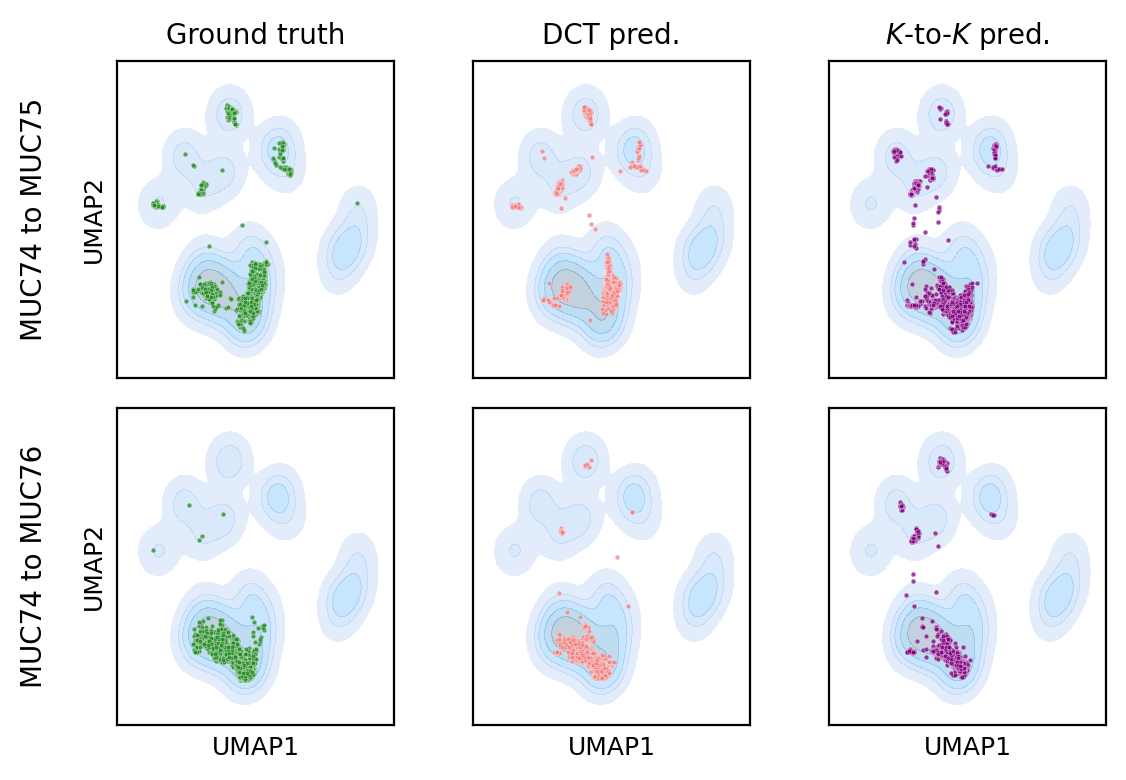

In [15]:
# plot projections (can run multiple times without reprojecting)

# style parameters
scatter_size = 3
scatter_alpha_target = 0.75
scatter_alpha_dct = 0.75
scatter_alpha_onehot = 0.75

kde_palette = 'Blues'
kde_alpha = 0.3
kde_fill = True
kde_thresh = 0.05
kde_levels = 6
kde_gridsize = 100

# colors
target_color = 'forestgreen'
dct_color = 'lightcoral'
onehot_color = 'purple'

# font sizes
title_fontsize = 10
label_fontsize = 9
row_label_fontsize = 10

# figure setup
fig, axes = plt.subplots(2, 3, figsize=(6, 4), dpi=200)

for row_idx, result in enumerate(projection_results):
    source_donor = result['source_donor']
    target_donor = result['target_donor']
    target_umap = result['target_umap']
    dct_umap = result['dct_umap']
    onehot_umap = result['onehot_umap']
    
    # get last 8 characters of donor IDs for row label
    source_label = 'MUC' + source_donor[-2:]
    target_label = 'MUC' + target_donor[-2:]
    
    # column 1: ground truth
    ax = axes[row_idx, 0]
    sns.kdeplot(
        x=full_umap_subsample[:, 0], 
        y=full_umap_subsample[:, 1],
        ax=ax,
        palette=kde_palette,
        fill=kde_fill,
        alpha=kde_alpha,
        thresh=kde_thresh,
        levels=kde_levels,
        gridsize=kde_gridsize
    )
    sns.scatterplot(
        x=target_umap[:, 0], 
        y=target_umap[:, 1],
        ax=ax,
        color=target_color,
        alpha=scatter_alpha_target,
        s=scatter_size
    )
    if row_idx == 0:
        ax.set_title('Ground truth', fontsize=title_fontsize)
    if row_idx == 1:
        ax.set_xlabel('UMAP1', fontsize=label_fontsize)
    if ax == axes[0, 0] or ax == axes[1, 0]:
        ax.set_ylabel('UMAP2', fontsize=label_fontsize)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    
    # row label on the left
    ax.text(-0.3, 0.5, f'{source_label} to {target_label}', 
           transform=ax.transAxes, rotation=90, 
           va='center', ha='center', fontsize=row_label_fontsize)

    # column 2: dct predictions
    ax = axes[row_idx, 1]
    sns.kdeplot(
        x=full_umap_subsample[:, 0], 
        y=full_umap_subsample[:, 1],
        ax=ax,
        palette=kde_palette,
        fill=kde_fill,
        alpha=kde_alpha,
        thresh=kde_thresh,
        levels=kde_levels,
        gridsize=kde_gridsize
    )
    sns.scatterplot(
        x=dct_umap[:, 0], 
        y=dct_umap[:, 1],
        ax=ax,
        color=dct_color,
        alpha=scatter_alpha_dct,
        s=scatter_size
    )
    if row_idx == 0:
        ax.set_title('DCT pred.', fontsize=title_fontsize)
    if row_idx == 1:
        ax.set_xlabel('UMAP1', fontsize=label_fontsize)
    if ax == axes[0, 2] or ax == axes[1, 2]:
        ax.set_ylabel('UMAP2', fontsize=label_fontsize)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

    # column 3: onehot predictions
    ax = axes[row_idx, 2]
    sns.kdeplot(
        x=full_umap_subsample[:, 0], 
        y=full_umap_subsample[:, 1],
        ax=ax,
        palette=kde_palette,
        fill=kde_fill,
        alpha=kde_alpha,
        thresh=kde_thresh,
        levels=kde_levels,
        gridsize=kde_gridsize
    )
    sns.scatterplot(
        x=onehot_umap[:, 0], 
        y=onehot_umap[:, 1],
        ax=ax,
        color=onehot_color,
        alpha=scatter_alpha_onehot,
        s=scatter_size
    )
    if row_idx == 0:
        ax.set_title(r'$K$-to-$K$ pred.', fontsize=title_fontsize)
    # only bottom row
    if row_idx == 1:
        ax.set_xlabel('UMAP1', fontsize=label_fontsize)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()